# IY021 – All Experiments Trace Overview

Plots the mean ± SD fluorescence trace for every (experiment, group, channel) combination in
`EXP-25-IY008/4_transformed_exp_time_series/`, including groups previously excluded due to unknown TF.

**TF identity** is resolved in priority order:
1. Experiment-specific OMERO metadata from `get_exp_summary` (acquisition files)
2. Lab strain database (`EXP-25-IY008/strain_tf_database.csv`)
3. `Unknown (group X)` as final fallback

**Excluded:** Experiment 18446 — not properly recorded, excluded from all analyses.

**Layout:** one figure per experiment — rows = groups, columns = GFP / mCherry channels.

In [1]:
import re
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, "/home/ianyang/wela/src")
sys.path.insert(0, "/home/ianyang/alibylite/src")

IY021_DIR   = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY021")
DATA_DIR    = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series")
STRAIN_DB   = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/strain_tf_database.csv")
ACQ_BASE    = "/home/ianyang/alibylite/high_quality_data_analysis"
META_COLS   = ["id", "group", "experiment"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})
sns.set_theme(style="whitegrid", palette="colorblind")

palette   = sns.color_palette("colorblind")
GFP_COLOR = palette[2]   # green
MC_COLOR  = palette[3]   # reddish-orange

## 1. Build TF and Condition Maps

In [2]:
from wela.get_exp_conditions import get_exp_summary

# 18446 is excluded — not properly recorded.
OMID_MAP = {
    "18360": "18360_2020_01_04_steadystate_glucose_2min_01",
    "18464": "18464_2020_01_20_steadystate_glucose_756S_2min_mock_00",
    "18589": "18589_2020_02_10_steadystate_glucose_898S_2w2_01",
    "19316": "19316_2020_10_26_steadystate_glucose_144m_2w2_00",
    "19330": "19330_2020_11_02_steadystate_glucose_1345m_2w2_00",
    "19391": "19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00",
    "19392": "19392_2020_11_12_steadystate_glucose_898m_2w0p01_00",
    "19394": "19394_2020_11_12_steadystate_glucose_1345m_2w0p1_00",
    "19554": "19554_2020_12_06_steadystate_glucose_2w0p01_900m_00",
    "19566": "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01",
    "20213": "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00",
}

# --- Load lab strain database (group_id, channel, tf) ---
strain_db = pd.read_csv(STRAIN_DB)
# Build lookup: (group_id, channel) -> tf
STRAIN_LOOKUP = {
    (str(row["group_id"]), row["channel"]): row["tf"]
    for _, row in strain_db.iterrows()
}
print(f"Strain database loaded: {len(STRAIN_LOOKUP)} entries")

# --- Build per-experiment TF map from OMERO acquisition files ---
# TF_MAP[(exp_id, group_id, channel)] -> tf name
TF_MAP        = {}
CONDITION_MAP = {}

for exp_id, omid in sorted(OMID_MAP.items()):
    acqs = glob.glob(f"{ACQ_BASE}/{omid}/*Acq.txt")
    logs = glob.glob(f"{ACQ_BASE}/{omid}/*log.txt")
    if not acqs or not logs:
        print(f"  {exp_id}: acquisition files not found")
        continue

    summary_df, tf_df, _ = get_exp_summary(acqs[0], logs[0])
    pumps = summary_df["pump_contents"].values[0]

    # Steady-state condition = pump 2 (index 1)
    ss_pump = pumps[1] if isinstance(pumps, list) and len(pumps) > 1 else str(pumps)
    if isinstance(pumps, list) and len(pumps) == 2 and pumps[0] == pumps[1]:
        CONDITION_MAP[exp_id] = f"{ss_pump.replace(' in SC', '')} (mock/steady)"
    else:
        CONDITION_MAP[exp_id] = ss_pump.replace(" in SC", "")

    if not tf_df.empty:
        for _, row in tf_df.iterrows():
            g = str(row["group"]).strip()
            TF_MAP[(exp_id, g, "GFP")]     = str(row["GFP TF"]).strip()
            TF_MAP[(exp_id, g, "mCherry")] = str(row["mCherry TF"]).strip()

print(f"\nConditions ({len(CONDITION_MAP)} experiments):")
for k, v in sorted(CONDITION_MAP.items()):
    print(f"  {k}: {v}")
print(f"\nOMERO TF entries resolved: {len(TF_MAP) // 2} groups")

Strain database loaded: 28 entries
=== EXPERIMENT SUMMARY ===

📸 IMAGING SETUP (from acquisition file):
• Channels: ['Brightfield', 'GFP', 'mCherry']
• Exposure times: [30, 30, 100] ms
• Camera EM gain: 270

⏱️ TIME-LAPSE SETTINGS:
• Time interval: 120 seconds (2.0 minutes)
• Number of timepoints: 540
• Total experiment time: 64800 seconds (18.0 hours)

🧪 MICROFLUIDICS SETUP:
• Number of pumps: 2
• Pump rates: [[0.0], [4.0]]
• Pump contents: ['2% glucose in SC', '0.1% glucose in SC']
• Number of switches: 1
• Switch volumes: 50
• Switch rates: 100
• Switch times: [180]

🔬 MICROSCOPE SETUP (from log file):
• Microscope: Batgirl
• Date: 2020-01-03 00:00:00
• Experiment start time: 2020-01-03 18:56:49
• Capture of the first image: 2020-01-03 18:56:50
• MultiDGUI commit: a28757e2e9fa60027dcf8e290ee9b66e6372e32c
• Experimental details: Aim:   Strain:   Comments:

💾 OMERO INFORMATION:
• Project: SteadystateGlucose
• Tags: ['03-Jan-2020', 'Batgirl', 'GFP', 'mCherry', '3 chamber', '898.Msn2-GF

## 2. Discover Files

In [3]:
_FILE_RE = re.compile(
    r"^(\d+)_.*_group_(.+?)_(GFP|mCherry)_time_series$"
)

def get_tf(exp_id, group_id, channel):
    """Resolve TF: OMERO metadata > lab strain database > Unknown fallback."""
    # 1. Experiment-specific OMERO metadata
    omero = TF_MAP.get((exp_id, group_id, channel))
    if omero:
        return omero
    # 2. Lab strain database (group_id is strain-level, channel-specific)
    strain = STRAIN_LOOKUP.get((group_id, channel))
    if strain:
        return strain
    return f"Unknown (group {group_id})"

EXCLUDED_EXPERIMENTS = {"18446"}  # not properly recorded

records = []
for csv_path in sorted(DATA_DIR.glob("*.csv")):
    m = _FILE_RE.match(csv_path.stem)
    if m is None:
        print(f"  Skipping (unrecognised pattern): {csv_path.name}")
        continue
    exp_id, group_id, channel = m.group(1), m.group(2), m.group(3)
    if exp_id in EXCLUDED_EXPERIMENTS:
        continue
    records.append({
        "path":      csv_path,
        "exp_id":    exp_id,
        "group_id":  group_id,
        "channel":   channel,
        "condition": CONDITION_MAP.get(exp_id, "unknown"),
        "tf":        get_tf(exp_id, group_id, channel),
    })

file_df = pd.DataFrame(records).sort_values(["exp_id", "group_id", "channel"])
print(f"Found {len(file_df)} files across {file_df['exp_id'].nunique()} experiments")
display(file_df[["exp_id", "group_id", "channel", "condition", "tf"]].reset_index(drop=True))

Found 66 files across 11 experiments


,exp_id,group_id,channel,condition,tf
0,18360,1106,GFP,0.1% glucose,Mig2
1,18360,1106,mCherry,0.1% glucose,Mig1
2,18360,898,GFP,0.1% glucose,Msn2
3,18360,898,mCherry,0.1% glucose,Mig1
4,18360,900,GFP,0.1% glucose,Mig1
...,...,...,...,...,...
61,20213,1344,mCherry,0.01% glucose,Msn2
62,20213,1346,GFP,0.01% glucose,Nrg1
63,20213,1346,mCherry,0.01% glucose,Msn2
64,20213,1347,GFP,0.01% glucose,Rtg1


## 3. Plot All Experiments

In [4]:
def plot_trace(ax, csv_path, color):
    """Load CSV, plot mean ± SD across cells. Returns (n_cells, n_timepoints)."""
    df = pd.read_csv(csv_path)
    time_cols = [c for c in df.columns if c not in META_COLS]
    X = df[time_cols].values.astype(float)
    t = np.arange(X.shape[1])
    mean = np.nanmean(X, axis=0)
    sd   = np.nanstd(X,  axis=0, ddof=1)
    ax.plot(t, mean, color=color, linewidth=1.8)
    ax.fill_between(t, mean - sd, mean + sd, color=color, alpha=0.2)
    ax.set_xlabel("Timepoint / 2 min")
    ax.set_ylabel("Fluorescence / a.u.")
    ax.grid(alpha=0.3)
    return X.shape[0], X.shape[1]

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_trace_overview_exp18360.png


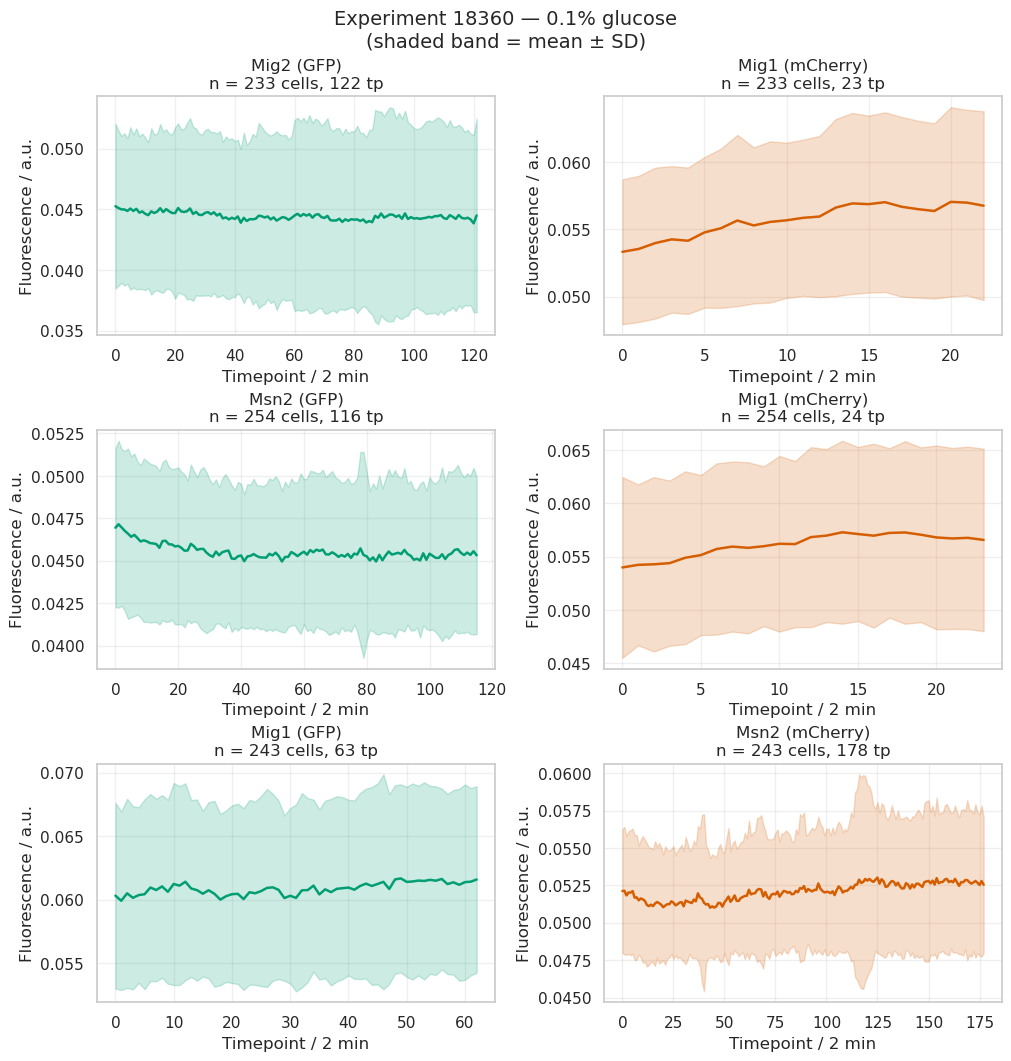

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_trace_overview_exp18464.png


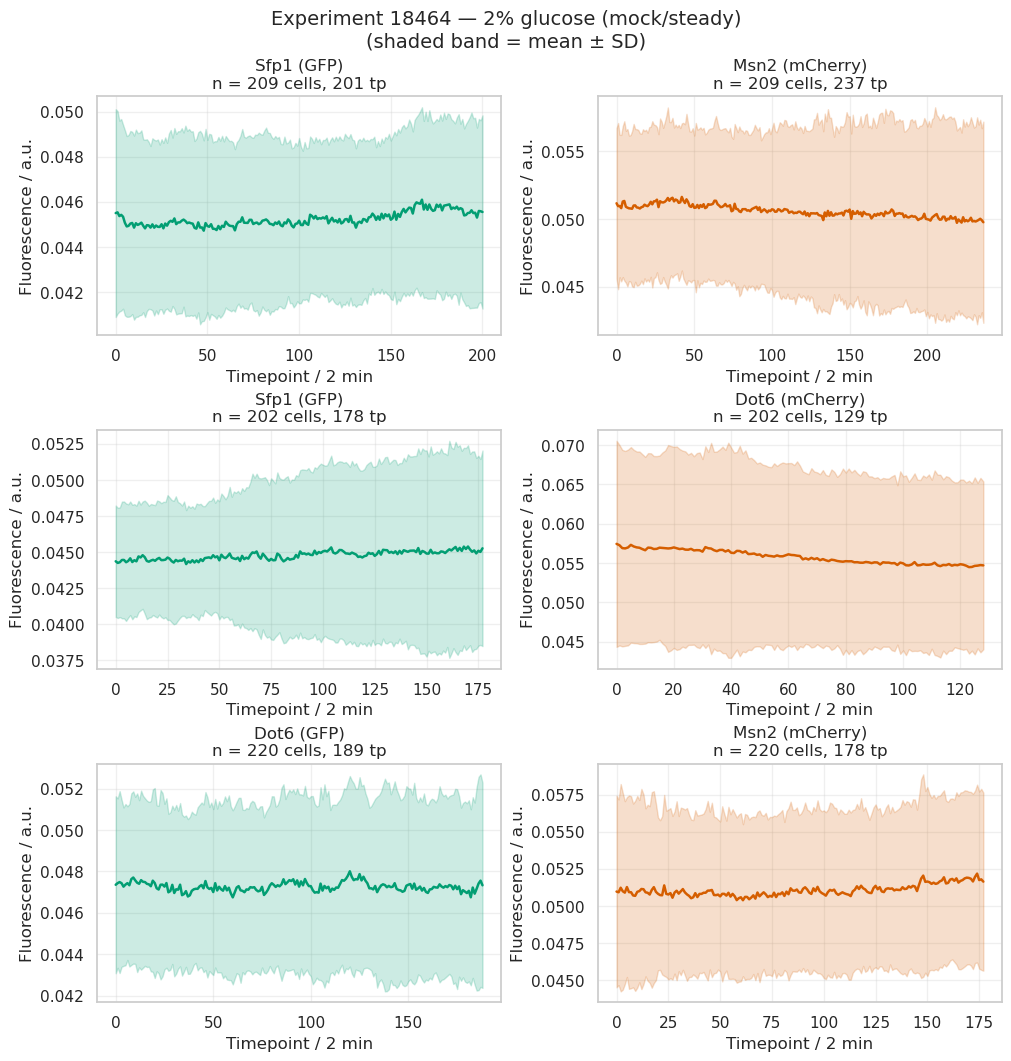

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_trace_overview_exp18589.png


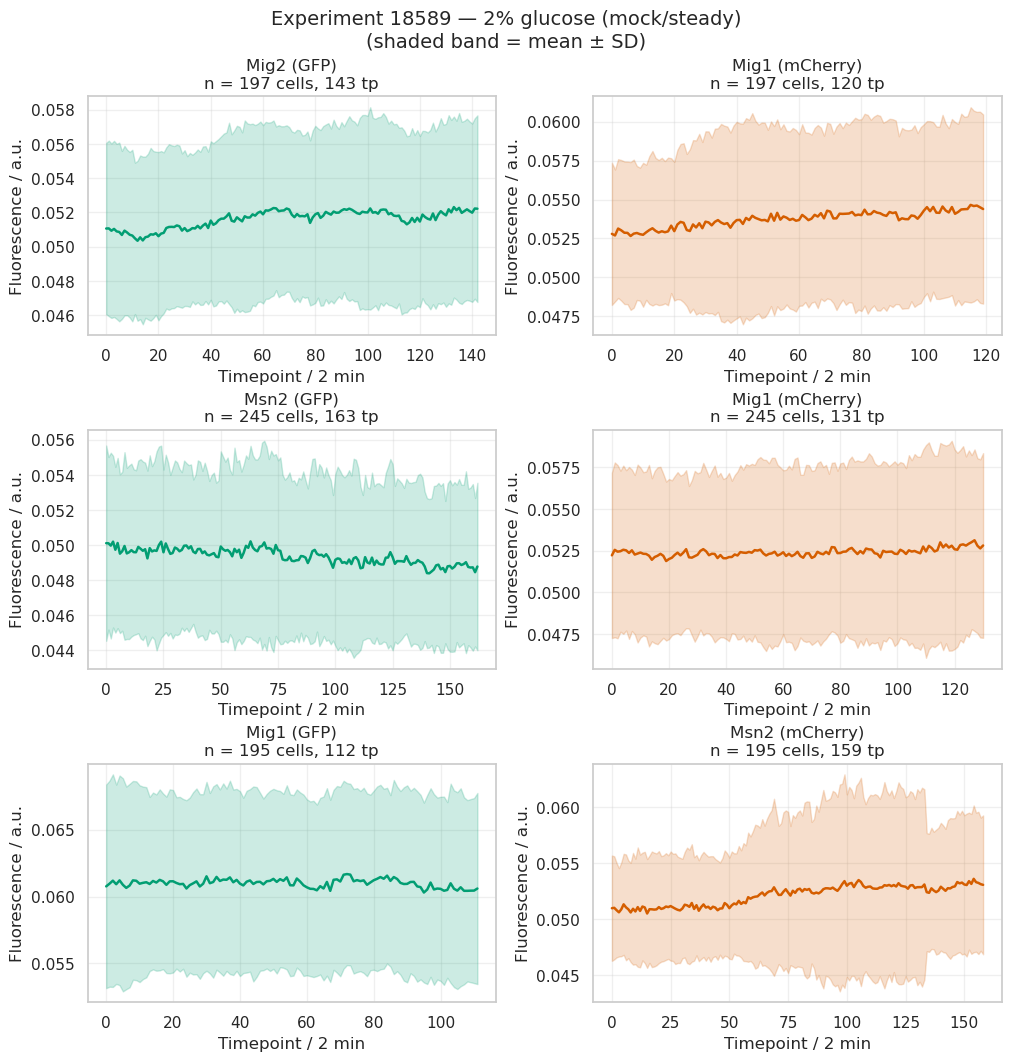

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_trace_overview_exp19316.png


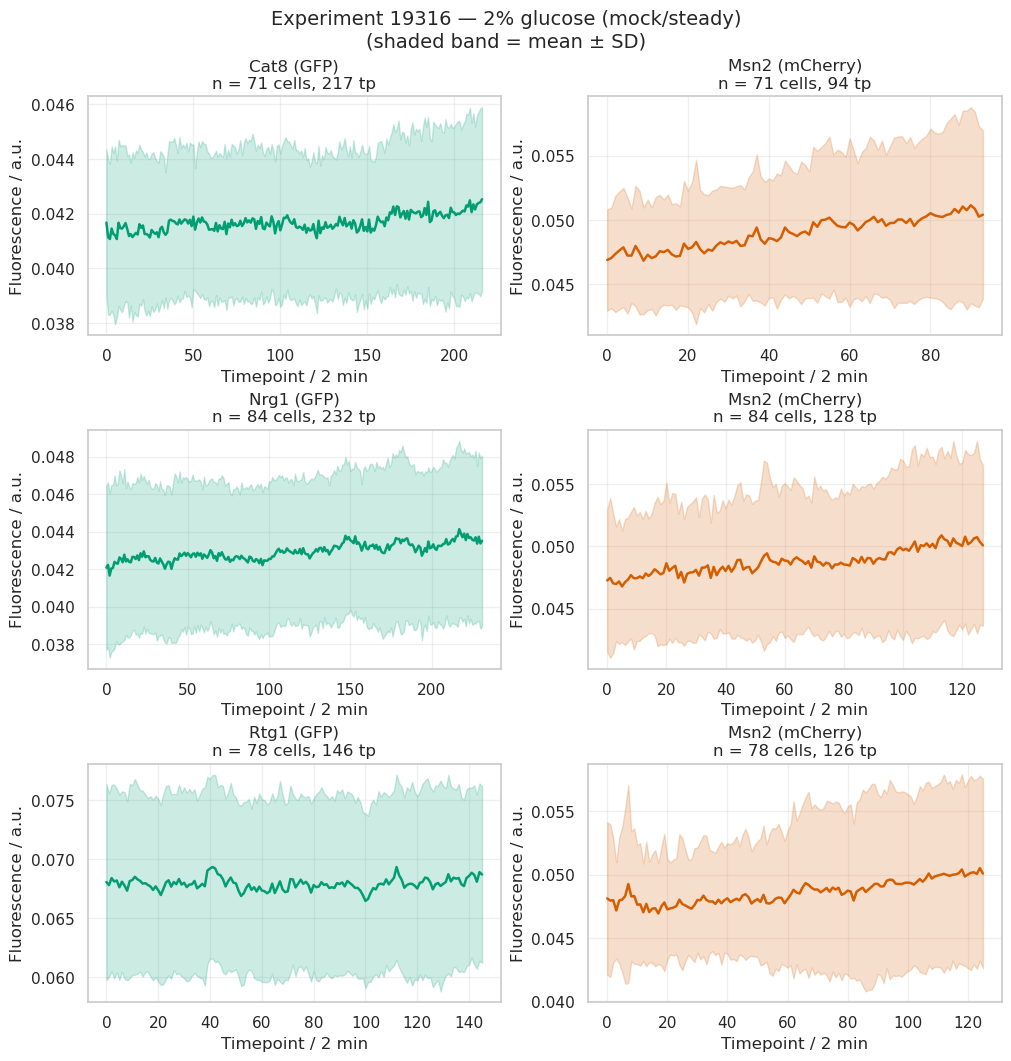

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_trace_overview_exp19330.png


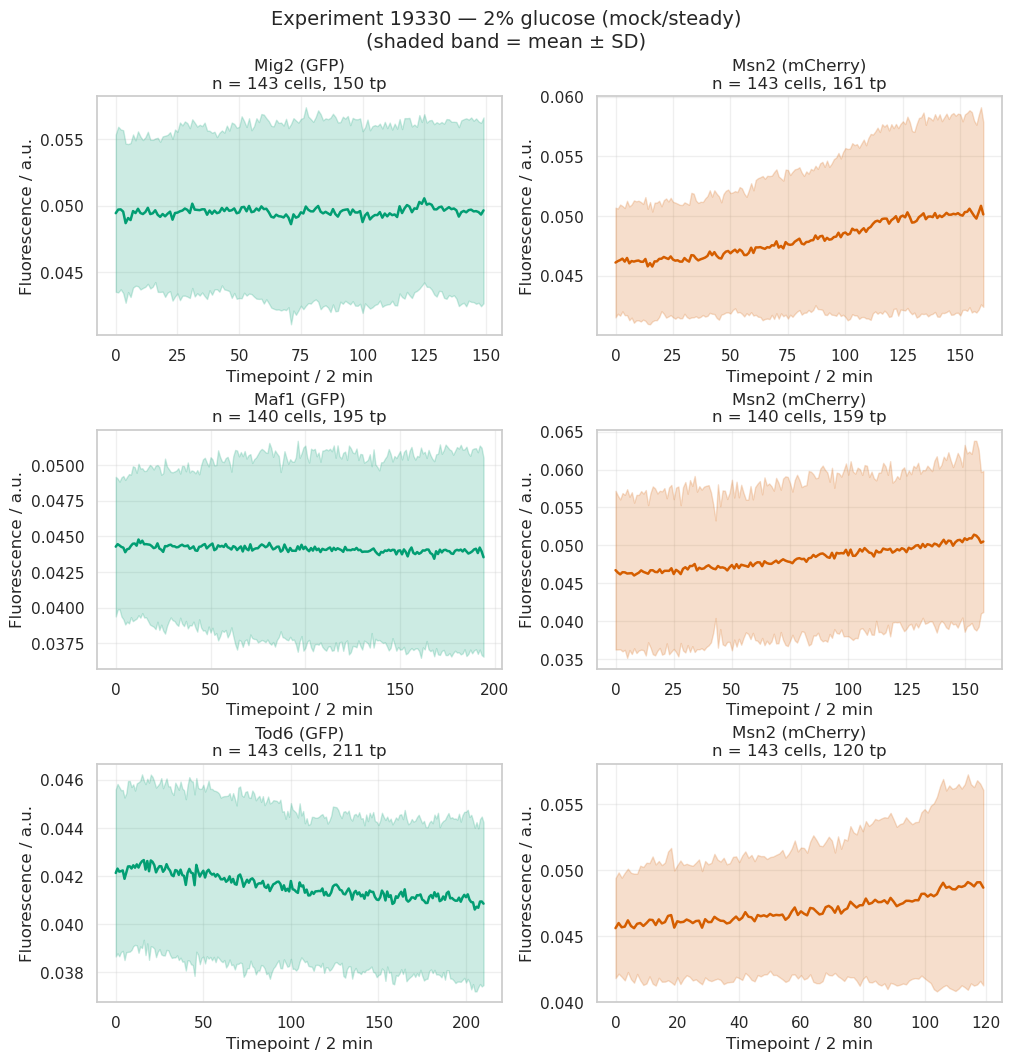

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_trace_overview_exp19391.png


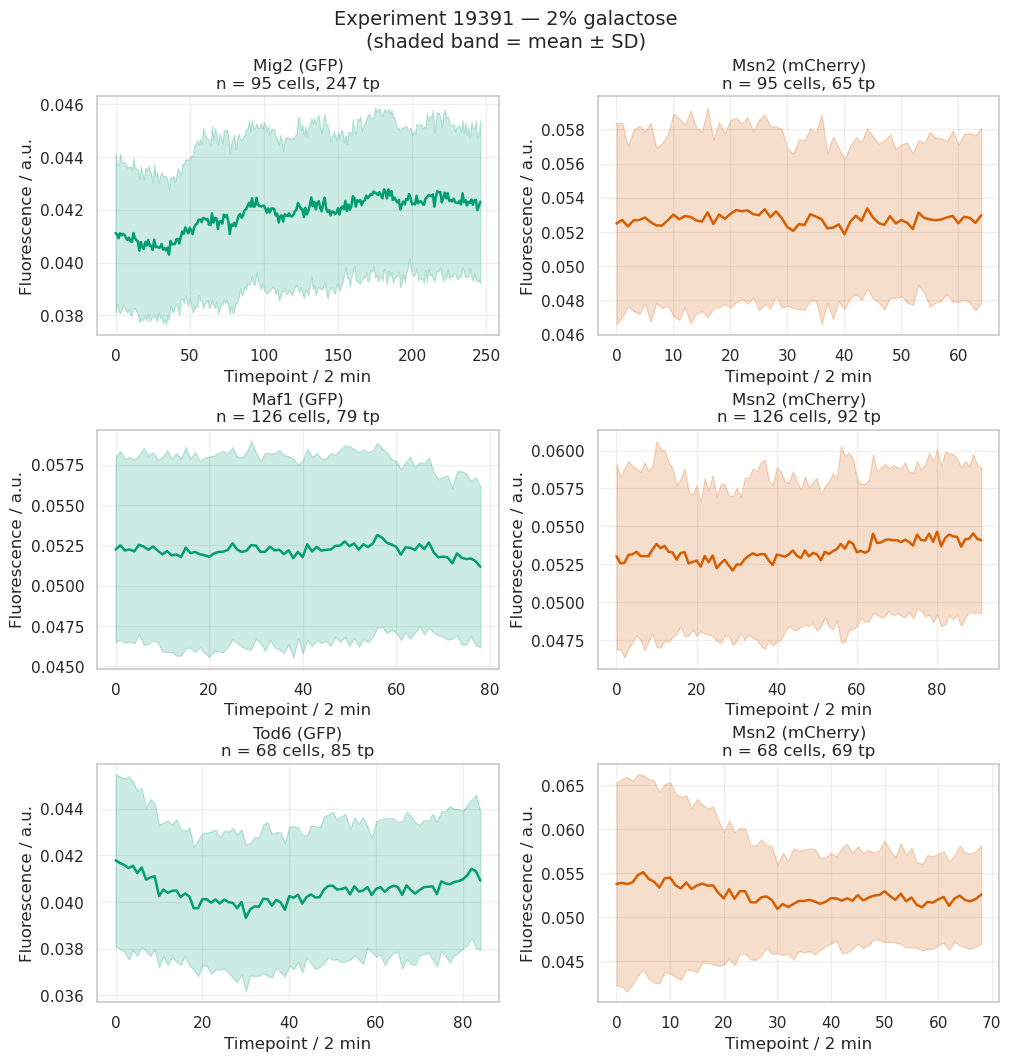

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_trace_overview_exp19392.png


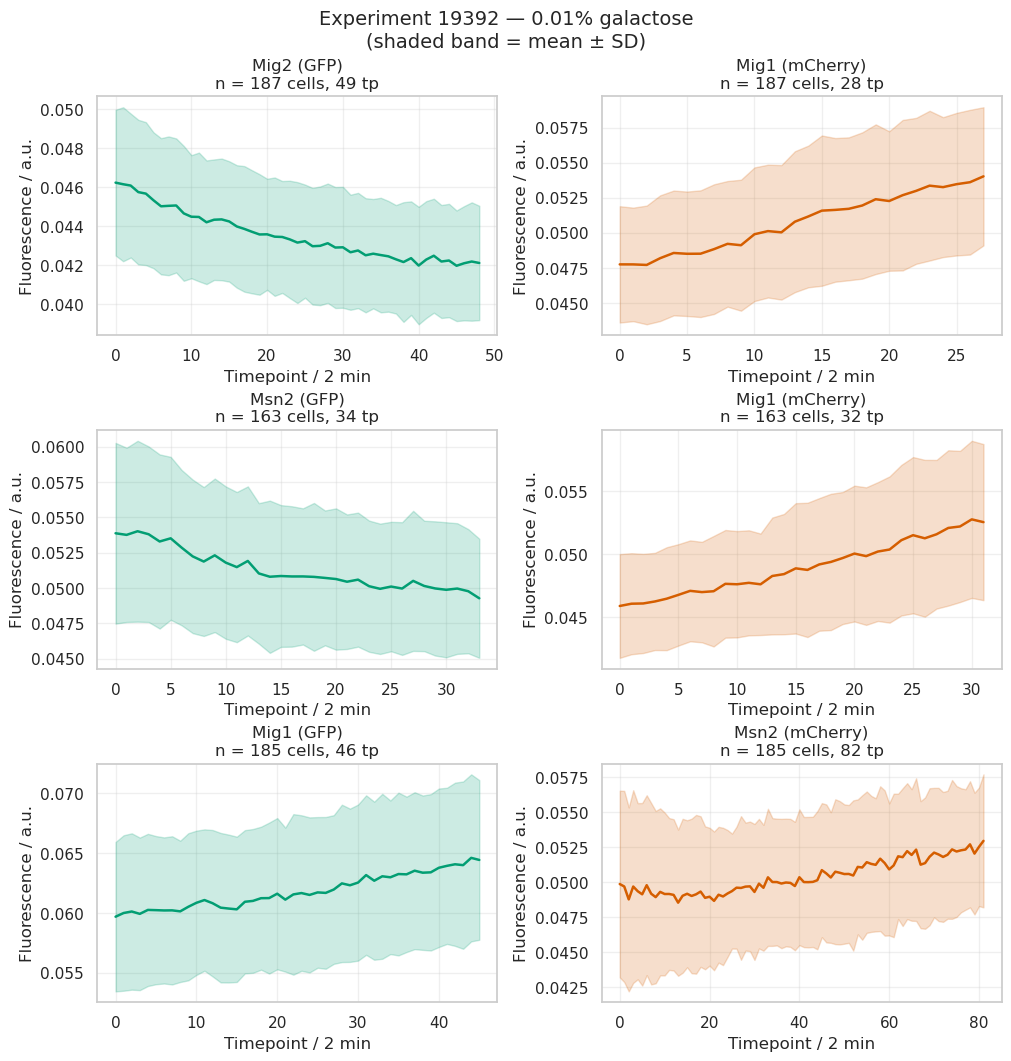

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_trace_overview_exp19394.png


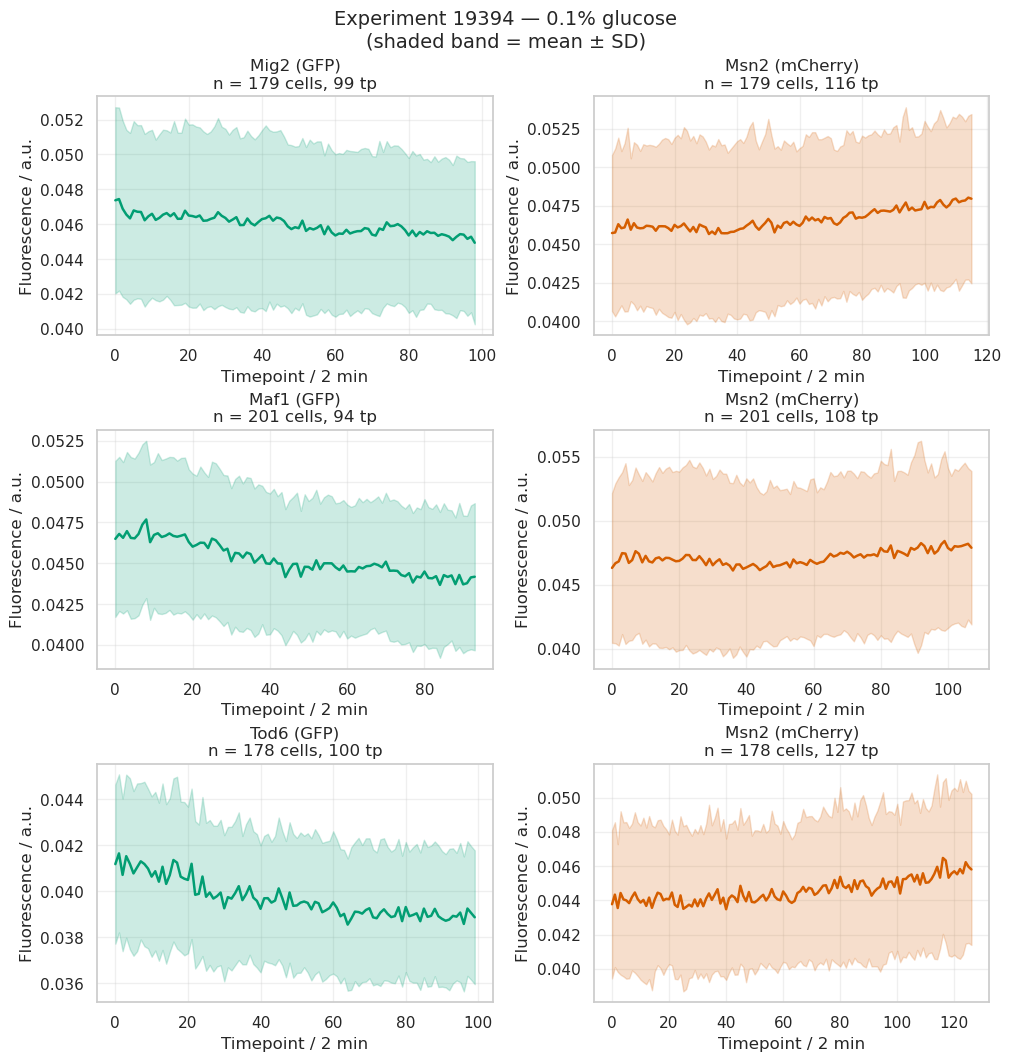

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_trace_overview_exp19554.png


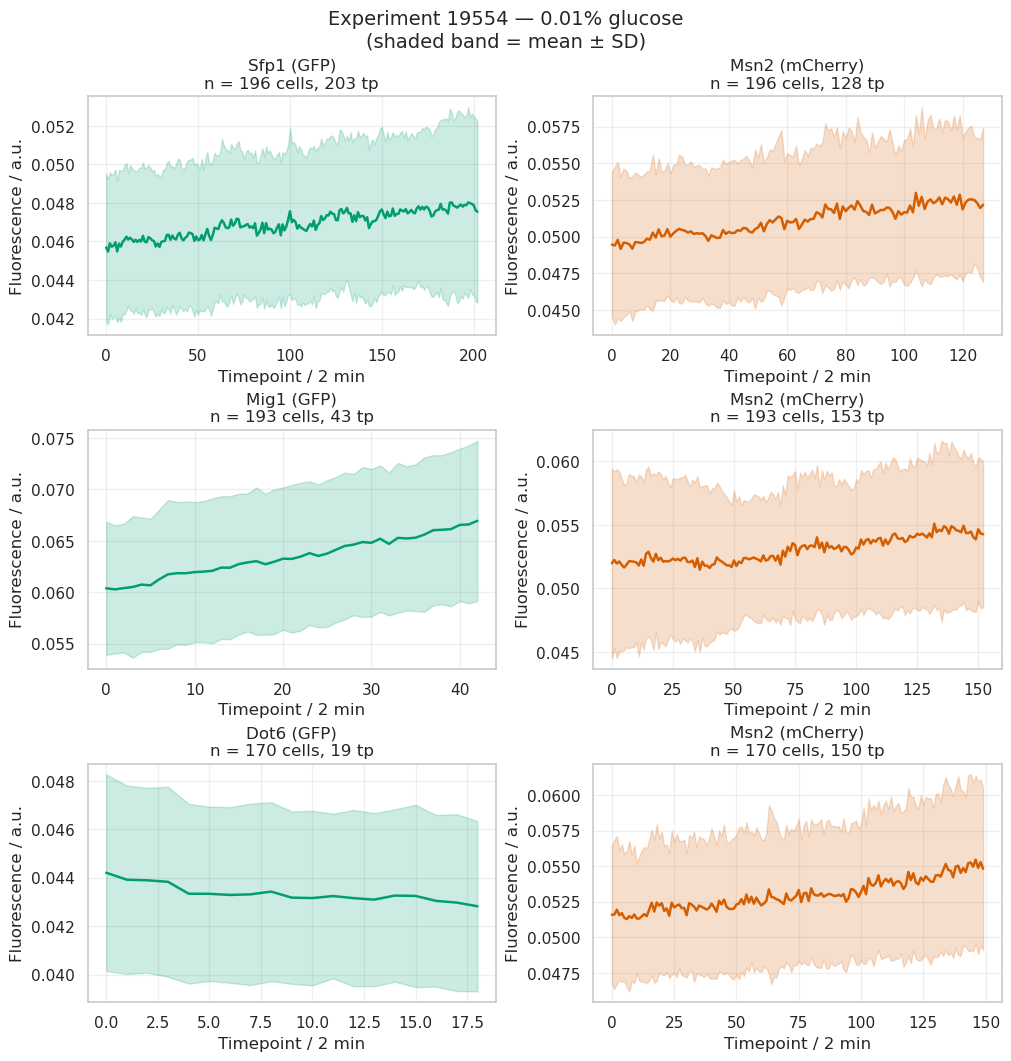

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_trace_overview_exp19566.png


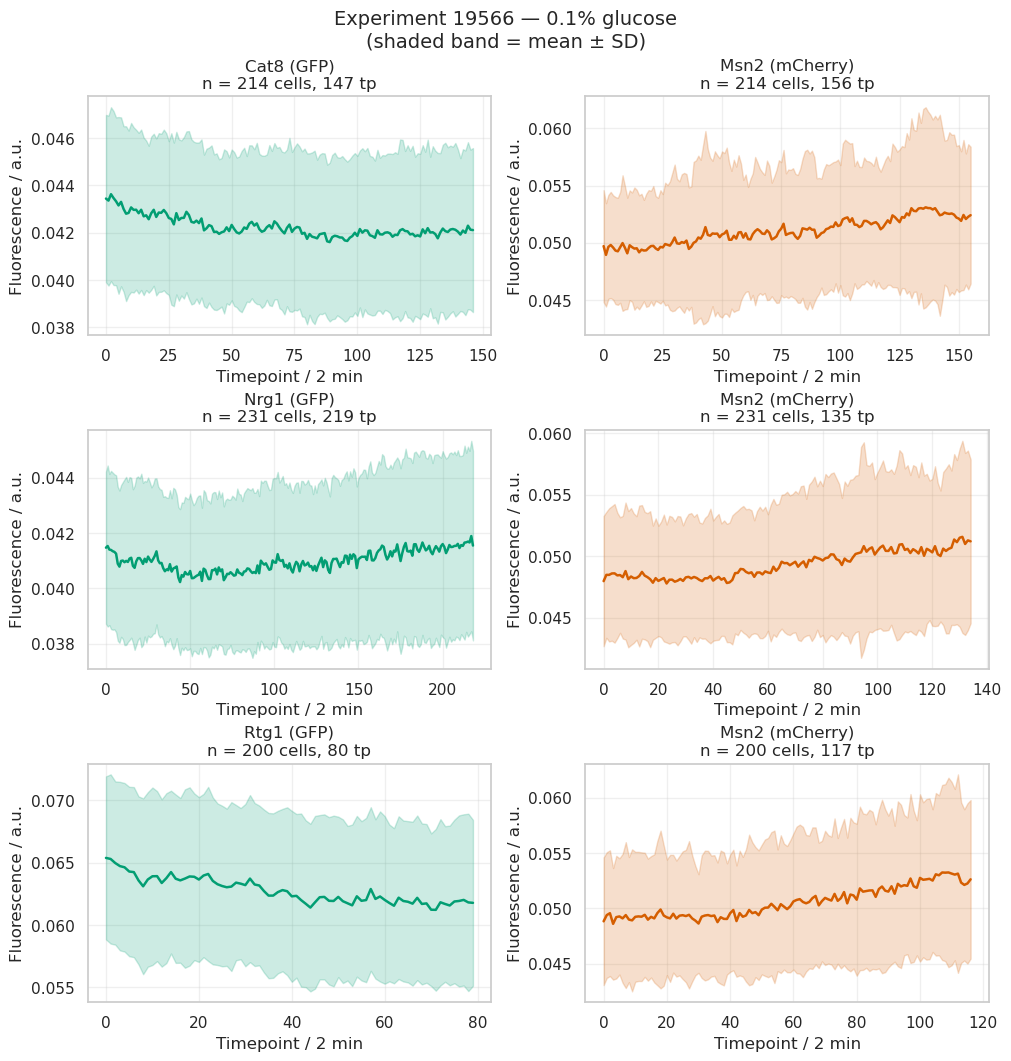

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_trace_overview_exp20213.png


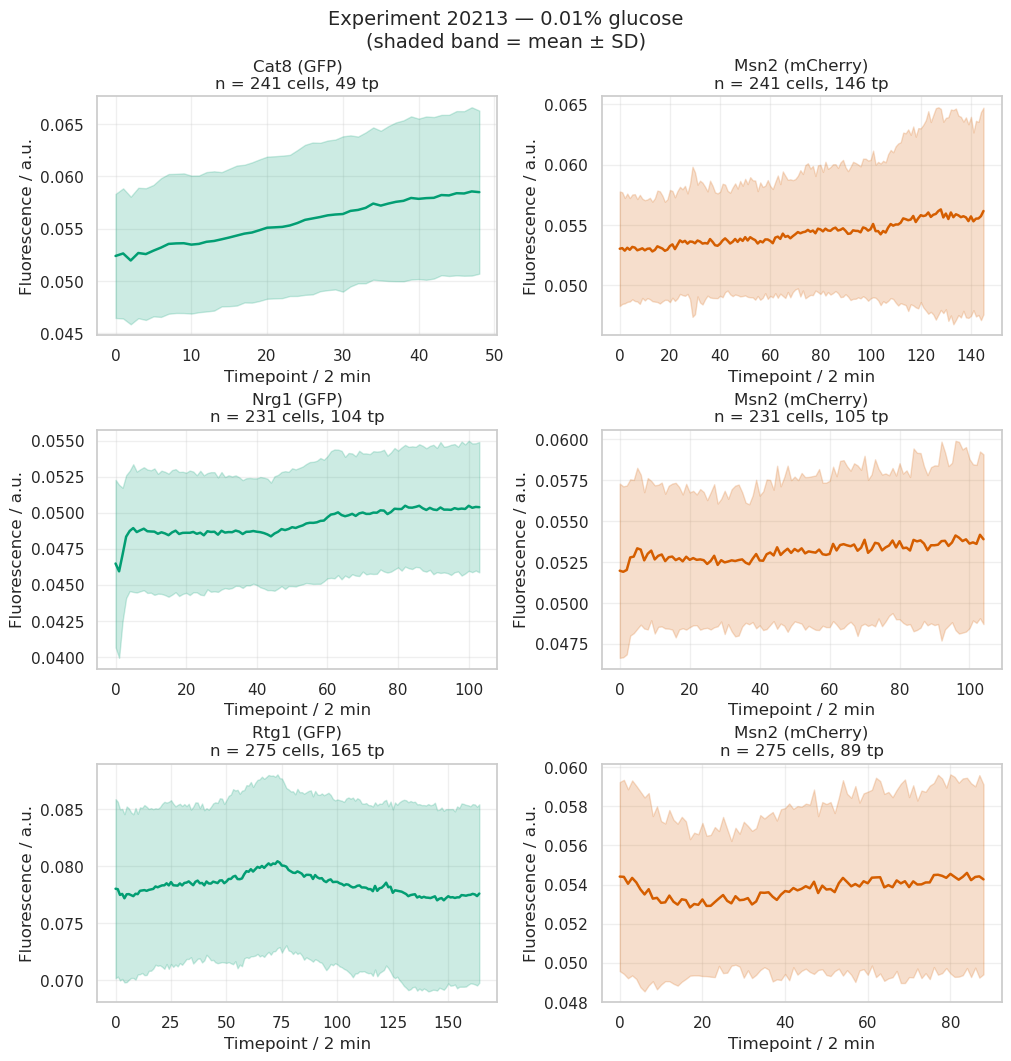

In [5]:
for exp_id in sorted(file_df["exp_id"].unique()):
    exp_data  = file_df[file_df["exp_id"] == exp_id]
    condition = CONDITION_MAP.get(exp_id, "unknown")
    groups    = sorted(exp_data["group_id"].unique())
    channels  = ["GFP", "mCherry"]

    n_rows = len(groups)
    n_cols = len(channels)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 3.5 * n_rows),
        constrained_layout=True,
    )
    axes = np.asarray(axes).reshape(n_rows, n_cols)

    for row, group_id in enumerate(groups):
        for col, channel in enumerate(channels):
            ax = axes[row, col]
            match = exp_data[
                (exp_data["group_id"] == group_id) &
                (exp_data["channel"]  == channel)
            ]
            if match.empty:
                ax.set_visible(False)
                continue
            color   = GFP_COLOR if channel == "GFP" else MC_COLOR
            tf_name = match.iloc[0]["tf"]
            n_cells, n_tp = plot_trace(ax, match.iloc[0]["path"], color)
            ax.set_title(
                f"{tf_name} ({channel})\n"
                f"n = {n_cells} cells, {n_tp} tp"
            )

    fig.suptitle(
        f"Experiment {exp_id} — {condition}\n"
        f"(shaded band = mean ± SD)",
        fontsize=14,
    )
    fig_path = IY021_DIR / f"IY021_trace_overview_exp{exp_id}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()